## Tarea1 -> IA Generativa Aplicada a las Ciencias Sociales y la Gestión Pública

El trabajo se centrará en buscar relación entre las variables de ser beneficiario del programa social Pensión 65 y el nivel educativo dentro de los hogares beneficiarios.


1. Renato Christian Gates Rojas (20181179)

La literatura existente sobre los efectos de programas de pensiones no  contributivas, como "Pensión 65", es extensa y abarca diversas partes del  mundo. No obstante, se observa una menor cantidad de estudios que aborden  el impacto en otros miembros del hogar con respecto a los beneficiarios. Dentro de las familias ante cambios en el ingreso al recibir dinero extra, la literatura indica que las  transferencias hechas para las personas mayores, como es el caso de las  pensiones sociales, los beneficiarios no son únicamente los afiliados, sino  también los demás miembros del hogar entre ellos los niños (Jense, 2004).

Existe una amplia literatura sobre los diversos efectos en educación  alrededor de distintos países en los que se indica que existe un aumento en la  escolarización cuando existe un beneficiario por algún tipo de pensión social en  el hogar para países como Sudáfrica, México, Tailandia y Brasil (Edmonds, 2006;  Gutierrez, Juarez & Rubli, 2017; Herrmann, Leckcivilize & Zenker, 2021;  Carvalho Filho, 2012; Hoffman, 2010). En términos generales, existe un efecto  positivo en un aumento en la matrícula escolar; sin embargo, esto varía en  distintos puntos. Para el caso de México, se encontró un mayor efecto en las  niñas que los niños y que no hubo distinción con respecto al sexo del beneficiario

In [351]:
from google.colab import drive
drive.mount('/content/drive')

Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [353]:
# Ruta a los datos
RUTA_DATA = '/content/drive/MyDrive/Programación QLAB/_data/'
RUTA_DATA

'/content/drive/MyDrive/Programación QLAB/_data/'

In [354]:
import os
archivos = os.listdir(RUTA_DATA)
print(archivos[:5])

['ESBAM_toshare_2015.dta', 'hh_varmembers_modiog.dta', 'hh_varmembers.dta', 'v_cap200_2.dta', 'v_cap1500.dta']


## 1. Bases de datos

La base de datos a utilizar es la "Encuesta de Salud y Bienestar del Adulto Mayor 2015". Esta muestra tiene la intención de realizar un seguimiendo a las personas beneficiarias del programa social Pensión 65. Fue elaborada por el MIDIS y el MEF, realizada en 12 departamentos: Amazonas, Ancash, Cajamarca, Huánuco, Junín, La Libertad, Loreto, Pasco, Piura, Puno y Lima


### Bases de datos a utilizar

| Base | descripción |  |
|---|---|---|
| `v_cap1500` | Empleo e ingresos
| `v_cap1300_1400` | Módulo de educación y Salud
| `v_cap200_2` | Caracteristica de miembros del hogar
| `hh_varmembers` | `count if missing(var)`

#Primera base de datos, limpiamos para luego juntarlas -> v_cap200_2, caracteristicas del hogar.







In [355]:
h_200 = pd.read_stata(RUTA_DATA + 'v_cap200_2.dta')

In [356]:
##resenper es la variable que nos indica el status final de la encuesta a los demás miembros del hogar
h_200['resenper'].value_counts()
print(h_200['resenper'].value_counts())

resenper
completa                              8946
am migró                               241
am fallecido                           222
am no presente                          93
rechazo                                 36
am no ubicado                           27
otro                                    22
incompleta                              19
se fue a un asilo o casa de reposo       2
se fue al extranjero                     1
Name: count, dtype: int64


In [357]:
#Nos quedamos solamente con las encuestas que fueron completas e incompletas de adultos mayores que se encontraban en el hogar.
h_200 = h_200[h_200['resenper'].isin(['completa', 'incompleta'])]

## Se eliminaron 644 observaciones

In [358]:
##Resfin es la variable que nos indica el status final de la encuesta a los demás miembros del hogar
h_200['resfin'].value_counts()
print(h_200['resfin'].value_counts())

resfin
completa                                    8886
incompleta                                    60
ausente                                       10
rechazo                                        9
fallecieron todos los miembros del hogar       0
am migró                                       0
am en el extranjero                            0
am en asilo                                    0
otro                                           0
no ubicado                                     0
Name: count, dtype: int64


In [359]:
#Además, nos quedamos con encuestas completas e incompletas a demás miembros del hogar.
h_200 = h_200[h_200['resfin'].isin(['completa', 'incompleta'])]

## Se eliminaron 19 observaciones

In [360]:
##p204 es la variable que nos indica si la persona encuestada es miembro del hogar
h_200['p204'].value_counts()
print(h_200['p204'].value_counts())

p204
si    8864
no      82
Name: count, dtype: int64


In [361]:
#Finalmente, con las personas encuestadas que son miembros del hogar. p204 & p206 = Si

h_200 = h_200[(h_200['p204'] == "si") | ((h_200['p204'] == "no") & (h_200['p206'] == "si"))]

# Se eliminaron 56 obs.

In [362]:
###Generamos el hhid identificador del hogar. Combinando el distrito y comunales.

# replace ccdi="04" if ccdi=="99" & distrito == "MAZAMARI - PANGOA"
h_200.loc[(h_200['ccdi'] == '99') & (h_200['distrito'] == 'MAZAMARI - PANGOA'), 'ccdi'] = '04'

# gen ubigeo = ccdd + ccpp + ccdi
h_200['ubigeo'] = h_200['ccdd'] + h_200['ccpp'] + h_200['ccdi']

#
h_200['hhid'] = h_200[['conglomerado', 'nselv', 'hogar_id', 'tot_hogar', 'ubigeo',
                         'codccpp', 'periodo', 'area', 'zona', 'mz',
                         'p14_dia', 'p14_mes']].astype(str).agg(''.join, axis=1)

print("unique hhid:  ", h_200['hhid'].nunique())

# generando el hhid unico por persona
h_200['id_person'] = h_200['hhid'].astype(str) + h_200['persona_id'].astype(str)

# Vemos las observaciones únicas (para ver el hogar)
print("unique id_person:", h_200['id_person'].nunique())

# Eliminamos los duplicados.
h_200 = h_200.drop_duplicates(subset='id_person', keep='first')
print("N =", len(h_200))

unique hhid:   3073
unique id_person: 8884
N = 8884


In [363]:
resumen_missing = pd.DataFrame({
    'dtype'   : h_200[['panel_id_adulto_mayor']].dtypes,
    'missings': h_200[['panel_id_adulto_mayor']].isnull().sum(),
    'pct_miss': (h_200[['panel_id_adulto_mayor']].isnull().sum() / len(h_200) * 100).round(3)
})
print(resumen_missing)

                         dtype  missings  pct_miss
panel_id_adulto_mayor  float64      1600     18.01


In [364]:
#Identificación de adulto

# generar una dummy de persona adulto mayor tiene ID válido (no missing y > 0)
h_200['am'] = (
    h_200['panel_id_adulto_mayor'].notna() &
    (h_200['panel_id_adulto_mayor'] > 0)
).astype(int)

# Contar adultos mayores identificados por hogar
h_200['AM'] = h_200.groupby('hhid')['am'].transform('sum')

#Eliminamos los hogares donde ningún adulto mayor fue identificado
h_200 = h_200[h_200['AM'] != 0]

print(f"\nN después del drop: {len(h_200):,}")  # Esperado: 8,540


N después del drop: 8,540


In [365]:
## Miembros del hogar y variables demográficas

# Variable 1: Miembros en el hogar
h_200['m'] = (
    (h_200['p204'] == 1) |
    ((h_200['p204'] == 2) & (h_200['p206'] == 1))
).astype(int)

h_200['totmiem'] = h_200.groupby('hhid')['m'].transform('sum')

#  male(variable auxiliar para la siguiente)
def categorizar_male(cod):
    if pd.isna(cod):    return np.nan
    elif cod == 'hombre': return 1
    elif cod == 'mujer':  return 0
    else:               return np.nan

h_200['male'] = h_200['p207'].apply(categorizar_male)

# Variable 2: Sexo — dummy final (1=mujer, 0=hombre)
def categorizar_sexo(cod):
    if pd.isna(cod):    return np.nan
    elif cod == 'mujer':  return 1
    elif cod == 'hombre': return 0
    else:               return np.nan

h_200['sexo'] = h_200['p207'].apply(categorizar_sexo)

print(h_200['male'].value_counts())
print(h_200['sexo'].value_counts())

# Variable 3: Edad
h_200['age'] = h_200['p208_1']

# Grupos de edad — Hombres (male==1)
h_200['g0_5m']   = ((h_200['age'] > 0)  & (h_200['age'] <= 5)  & (h_200['male'] == 1)).astype(int)  # niño 0-5yr
h_200['g6_13m']  = ((h_200['age'] > 5)  & (h_200['age'] <= 13) & (h_200['male'] == 1)).astype(int)  # niño 6-13yr
h_200['g14_17m'] = ((h_200['age'] > 13) & (h_200['age'] <= 17) & (h_200['male'] == 1)).astype(int)  # niño 14-17yr
h_200['g18_59m'] = ((h_200['age'] > 17) & (h_200['age'] <= 59) & (h_200['male'] == 1)).astype(int)  # hombre 18-59yr
h_200['g60m']    = ((h_200['age'] > 60)                         & (h_200['male'] == 1)).astype(int)  # hombre >60yr
h_200['g0_17m']  = ((h_200['age'] > 0)  & (h_200['age'] <= 17) & (h_200['male'] == 1)).astype(int)  # niño 0-17yr

# Grupos de edad Mujeres (male==0)
h_200['g0_5f']   = ((h_200['age'] > 0)  & (h_200['age'] <= 5)  & (h_200['male'] == 0)).astype(int)  # niña 0-5yr
h_200['g6_13f']  = ((h_200['age'] > 5)  & (h_200['age'] <= 13) & (h_200['male'] == 0)).astype(int)  # niña 6-13yr
h_200['g14_17f'] = ((h_200['age'] > 13) & (h_200['age'] <= 17) & (h_200['male'] == 0)).astype(int)  # niña 14-17yr
h_200['g18_59f'] = ((h_200['age'] > 17) & (h_200['age'] <= 59) & (h_200['male'] == 0)).astype(int)  # mujer 18-59yr
h_200['g60f']    = ((h_200['age'] > 60)                         & (h_200['male'] == 0)).astype(int)  # mujer >60yr
h_200['g0_17f']  = ((h_200['age'] > 0)  & (h_200['age'] <= 17) & (h_200['male'] == 0)).astype(int)  # niña 0-17yr



male
0    4320
1    4220
Name: count, dtype: int64
sexo
1    4320
0    4220
Name: count, dtype: int64


#Segunda base de datos, limpiamos para luego juntarlas -> v_cap1300_1400, Salud y educación de los otros miembros del hogar (Esto será importante para ver los resultados del efecto en educación).

In [366]:
h_1300_1400 = pd.read_stata(RUTA_DATA + 'v_cap1300_1400.dta')

Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

In [367]:

# ID de personas

# Corregir ccdi para Mazamari - Pangoa
h_1300_1400.loc[(h_1300_1400['ccdi'] == '99') & (h_1300_1400['distrito'] == 'MAZAMARI - PANGOA'), 'ccdi'] = '04'

# Construir ubigeo
h_1300_1400['ubigeo'] = h_1300_1400['ccdd'] + h_1300_1400['ccpp'] + h_1300_1400['ccdi']

# hhid — llave de hogar
h_1300_1400['hhid'] = h_1300_1400[['conglomerado', 'nselv', 'hogar_id', 'tot_hogar', 'ubigeo',
                                     'codccpp', 'periodo', 'area', 'zona', 'mz',
                                     'p14_dia', 'p14_mes']].astype(str).agg(''.join, axis=1)
print("Unique hhid:", h_1300_1400['hhid'].nunique())

# id_person — llave de persona
h_1300_1400['id_person'] = h_1300_1400['hhid'].astype(str) + h_1300_1400['persona_id'].astype(str)
print("Unique id_person:", h_1300_1400['id_person'].nunique())

# Eliminar duplicados por id_person
h_1300_1400 = h_1300_1400.drop_duplicates(subset='id_person', keep='first')
print(f"N tras drop duplicates: {len(h_1300_1400):,}")  # Esperado: 5,061


Unique hhid: 1983
Unique id_person: 5061
N tras drop duplicates: 5,061


#Tercera base de datos, limpiamos para luego juntarlas -> v_cap1500, Empleo e ingresos (Esto se puede utilizar para ver las variables de oferta laboral.).


In [368]:
h_1500 = pd.read_stata(RUTA_DATA + 'v_cap1500.dta')

In [369]:
# Corregir ccdi para Mazamari - Pangoa
h_1500.loc[(h_1500['ccdi'] == '99') & (h_1500['distrito'] == 'MAZAMARI - PANGOA'), 'ccdi'] = '04'

# Construir ubigeo
h_1500['ubigeo'] = h_1500['ccdd'] + h_1500['ccpp'] + h_1500['ccdi']

# hhid — llave de hogar
h_1500['hhid'] = h_1500[['conglomerado', 'nselv', 'hogar_id', 'tot_hogar', 'ubigeo',
                           'codccpp', 'periodo', 'area', 'zona', 'mz',
                           'p14_dia', 'p14_mes']].astype(str).agg(''.join, axis=1)
print("Unique hhid:", h_1500['hhid'].nunique())

# id_person — llave de persona (usa p1500_a, no persona_id)
h_1500['id_person'] = h_1500['hhid'].astype(str) + h_1500['p1500_a'].astype(str)
print("Unique id_person:", h_1500['id_person'].nunique())

# Eliminar duplicados por id_person
h_1500 = h_1500.drop_duplicates(subset='id_person', keep='first')
print(f"N tras drop duplicates: {len(h_1500):,}")  # Esperado: 3,821


Unique hhid: 1943
Unique id_person: 3821
N tras drop duplicates: 3,821


#Merge Final

In [370]:
cols_solo_1500 = ['id_person'] + [c for c in h_1500.columns
                                   if c not in h_1300_1400.columns]

final = h_1300_1400.merge(h_1500[cols_solo_1500], on='id_person', how='left')
print(f"N final tras merge: {len(final):,}")

duplicadas = [c for c in final.columns if c.endswith('_x') or c.endswith('_y')]

N final tras merge: 5,061


#Juntar con la última base de manera de append "ESBAM_toshare_2015" que cuenta con los puntajes SISFOH de los adultos mayores para verificar quiénes son elegibles a recibir el la transferencia de Pensión65.


In [371]:
esbam_2015 = pd.read_stata(RUTA_DATA + 'ESBAM_toshare_2015.dta')
final = pd.concat([final, esbam_2015], ignore_index=True)


/tmp/ipykernel_1684/164003258.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/164003258.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/164003258.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684

Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

/tmp/ipykernel_1684/164003258.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/164003258.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/164003258.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.


Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

/tmp/ipykernel_1684/164003258.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/tmp/ipykernel_1684/164003258.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/tmp/ipykernel_1684/164003258.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/tmp/ipyke

##Construcción del puntaje de corte para utilizar regresión discontinua. Se utilizará el comando RDrobust. El método de construcción de este indicador esta definido por el asesoramiento del profesor Javier Olivera en su momento.

In [372]:
!pip install rdrobust

Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

In [373]:

# Eliminar filas con hhid missing
final = final.dropna(subset=['hhid'])
print(f"N tras drop hhid missing: {len(final):,}")

# Máximos por hogar — propaga ifh de esbam a todos los miembros del hogar
final['IFH']  = final.groupby('hhid')['ifh'].transform('max')
final['ELIG'] = final.groupby('hhid')['eligible'].transform('max')
final['L1']   = final.groupby('hhid')['l1'].transform('max')

# Eliminar hogares sin puntaje IFH
final = final.dropna(subset=['IFH'])

# Running variable
final['Z']      = final['IFH'] - final['L1']
final['Z_ELIG'] = final['Z'] * final['ELIG']

# PSU y tratamiento
final['PSU']   = final.groupby('hhid')['psu_sample12'].transform('max')
final['TREAT'] = final.groupby('hhid')['treated_2015'].transform('max')

# Kernel
final['wgt'] = np.maximum(0, 1 - abs(final['Z']) / 0.33)


N tras drop hhid missing: 8,555


In [374]:
#Nos quedamos con las observaciones de menores de edad entre 0 y 17 años.
final = final[final['g0_17_t'] > 0]

##Variables para realizar la regresión

In [375]:
##Utilizamos la base final
Base_final = pd.read_stata(RUTA_DATA + 'hh_varmembers_modiog.dta')
# Matrícula escolar
Base_final['matricula'] = np.nan
Base_final.loc[(Base_final['p1305'] == ' si') & (Base_final['age'] <= 17), 'matricula'] = 1
Base_final.loc[(Base_final['p1305'] == ' no') & (Base_final['age'] <= 17), 'matricula'] = 0

/tmp/ipykernel_1684/1918933595.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/1918933595.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/1918933595.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1

Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

/tmp/ipykernel_1684/1918933595.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
/tmp/ipykernel_1684/1918933595.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.


Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

/tmp/ipykernel_1684/1918933595.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


In [376]:
# Horas de estudio (6-14 años)
Base_final['minutos_en_horas'] = np.nan
Base_final.loc[(Base_final['age'] >= 6) & (Base_final['age'] <= 14), 'minutos_en_horas'] = \
    Base_final['p1308a_1_minutos'] / 60

/tmp/ipykernel_1684/3157843859.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


Call: rdrobust
Number of Observations:                   688
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           269        419
Number of Unique Obs.             72         76
Number of Effective Obs.         192        200
Bandwidth Estimation           0.179      0.179
Bandwidth Bias                 0.269      0.269
rho (h/b)                      0.664      0.664

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.001    0.048    0.016   9.871e-01    [-0.093, 0.095]
Bias-Corrected     0.025    0.048    0.518   6.043e-01    [-0.069, 0.119]
Robust             0.025     

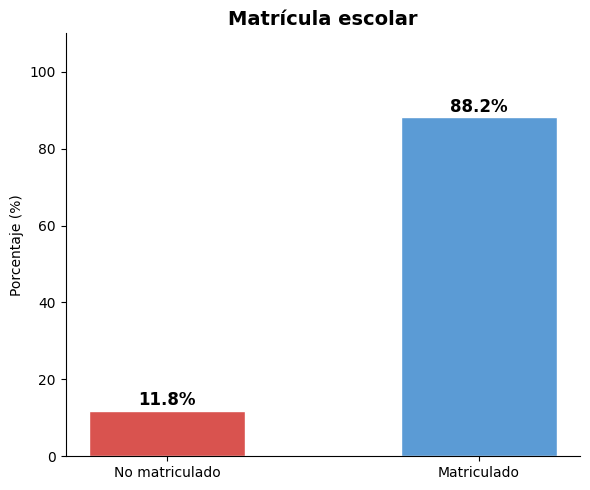

In [377]:
# Gráfico 1: Matrícula escolar
fig, ax = plt.subplots(figsize=(6, 5))

matricula_pct = Base_final['matricula'].value_counts(normalize=True).sort_index() * 100
ax.bar(['No matriculado', 'Matriculado'], matricula_pct.values,
       color=['#d9534f', '#5b9bd5'], edgecolor='white', width=0.5)
ax.set_title('Matrícula escolar', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 110)
for i, v in enumerate(matricula_pct.values):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

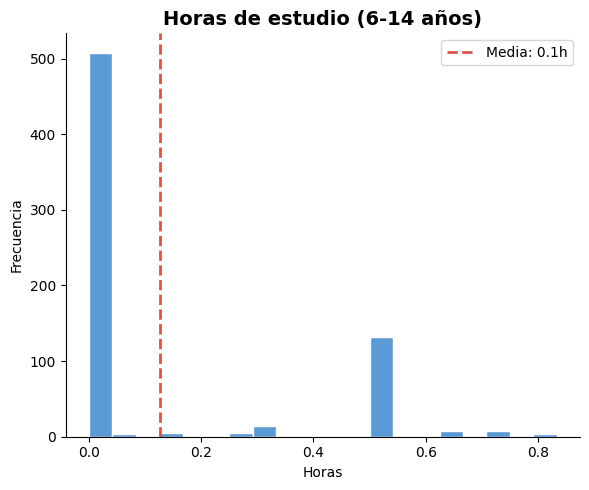

In [378]:
# Gráfico 2: Horas de estudio
fig, ax = plt.subplots(figsize=(6, 5))

horas = Base_final['minutos_en_horas'].dropna()
ax.hist(horas, bins=20, color='#5b9bd5', edgecolor='white')
ax.axvline(horas.mean(), color='#d9534f', linestyle='--', linewidth=2,
           label=f'Media: {horas.mean():.1f}h')
ax.set_title('Horas de estudio (6-14 años)', fontsize=14, fontweight='bold')
ax.set_xlabel('Horas')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [379]:
from rdrobust import rdrobust

# RD — Matrícula escolar
print("=== RD: Matrícula escolar ===")
rd_matricula = rdrobust(
    y          = Base_final['matricula'].dropna(),
    x          = Base_final.loc[Base_final['matricula'].notna(), 'W'],
    kernel     = 'triangular',
    bwselect   = 'mserd',
    scaleregul = 0,
    cluster    = Base_final.loc[Base_final['matricula'].notna(), 'PSU'],
    all        = True
)
print(rd_matricula)

# RD — Horas de estudio
print("\n=== RD: Horas de estudio ===")
rd_horas = rdrobust(
    y          = Base_final['minutos_en_horas'].dropna(),
    x          = Base_final.loc[Base_final['minutos_en_horas'].notna(), 'W'],
    kernel     = 'triangular',
    bwselect   = 'mserd',
    scaleregul = 0,
    cluster    = Base_final.loc[Base_final['minutos_en_horas'].notna(), 'PSU'],
    all        = True
)
print(rd_horas)

=== RD: Matrícula escolar ===
Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  1284
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           499        785
Number of Unique Obs.             93        105
Number of Effective Obs.          83        125
Bandwidth Estimation           0.072      0.072
Bandwidth Bias                 0.143      0.143
rho (h/b)                      0.504      0.504

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.142    0.053   -2.692   7.097e-03 

##Si bien la literatura indica que en otros países pensiones no contributivas o medios de transferencias condicionadas, aumentan la educación en términos extensivos (matricula) e intensivos (horas de estudio), la situacion actual del país con alta tasa de matricula implica que no se puedan apreciar resultados. Es por ese motivo, que las horas de estudio son más enriquecedoras. Sin embargo, debido a que solo a mayores de 14 años se le pregunta sus horas de estudio, no se ha podido apreciar con mayor magnitud el impacto.